# Employee Attrition Prediction

**Author:** Narjis Jebali 
**Date:** 2025-04-26  

## 1. Problem Definition
We aim to predict which employees are likely to leave the company (attrition), enabling HR to intervene early, reduce turnover costs, and retain talent. We'll enhance standard approaches by:
- Using advanced ensemble models (XGBoost, LightGBM)
- Adding explainability (SHAP)
- Assessing fairness (IBM AIF360)
- Employing robust cross-validation

## 2. Data Understanding
**Notes**  
-  Rows × Columns  
-  Data types & missing values  
-  Attrition distribution (target imbalance)


In [2]:
import pandas as pd
df = pd.read_csv('dataset.csv')
print(df.shape)
display(df.head())
display(df.info())
display(df['Attrition'].value_counts(normalize=True))

(1470, 30)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

None

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


Text(0.5, 1.0, 'Attrition Distribution')

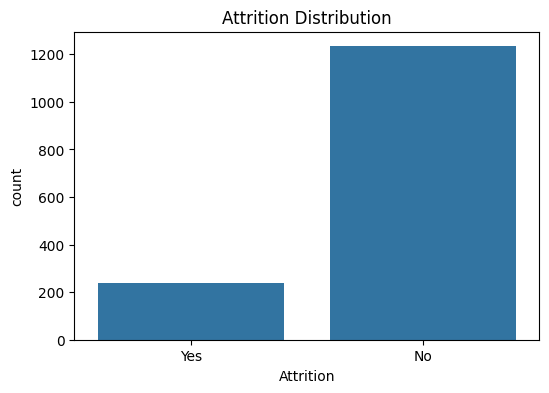

In [3]:
# Quick EDA (Exploratory Data Analysis): numeric summaries and pairwise target correlations
display(df.describe().T)
import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')

## 3. Data Processing
- Handle missing values  
- Encode categoricals (One-Hot / Ordinal)  
- Scale / normalize  
- Train/test split with stratification  
- SMOTE for class balance  
- Feature–Target Associations via Mutual Information

In [4]:
# 3a. Preprocessing pipeline setup
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Identify features
target = 'Attrition'
X = df.drop(columns=target)
y = df[target].map({'Yes':1,'No':0})

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)

# Categorical vs numerical
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('scale', StandardScaler(), num_cols)
])

# SMOTE for class balance
smote = SMOTE(random_state=42)

C:\Users\narji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Balanced target distribution: Counter({0: 986, 1: 986})


C:\Users\narji\AppData\Local\Temp\ipykernel_11492\3620553922.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


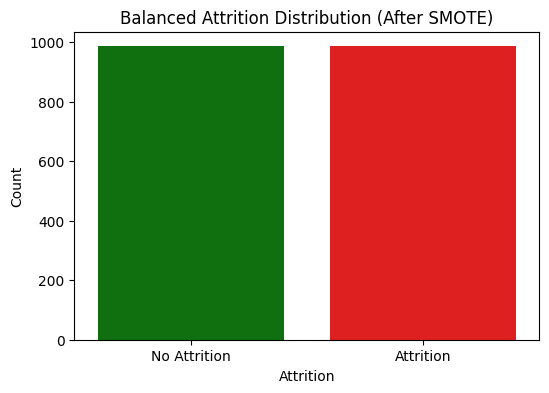

In [5]:
# 3b. Print new balanced target distribution

# Encode → SMOTE → inspect
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Fit & transform your training set
X_train_enc = preprocessor.fit_transform(X_train)

# 2) Resample to balance
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

# 3) Print the new counts
print("Balanced target distribution:", Counter(y_train_res))

# 4) Plot it
plt.figure(figsize=(6,4))
sns.countplot(
    x=y_train_res, 
    palette={'0': 'green', '1': 'red'}
)
plt.xticks([0,1], ['No Attrition','Attrition'])
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.title('Balanced Attrition Distribution (After SMOTE)')
plt.show()


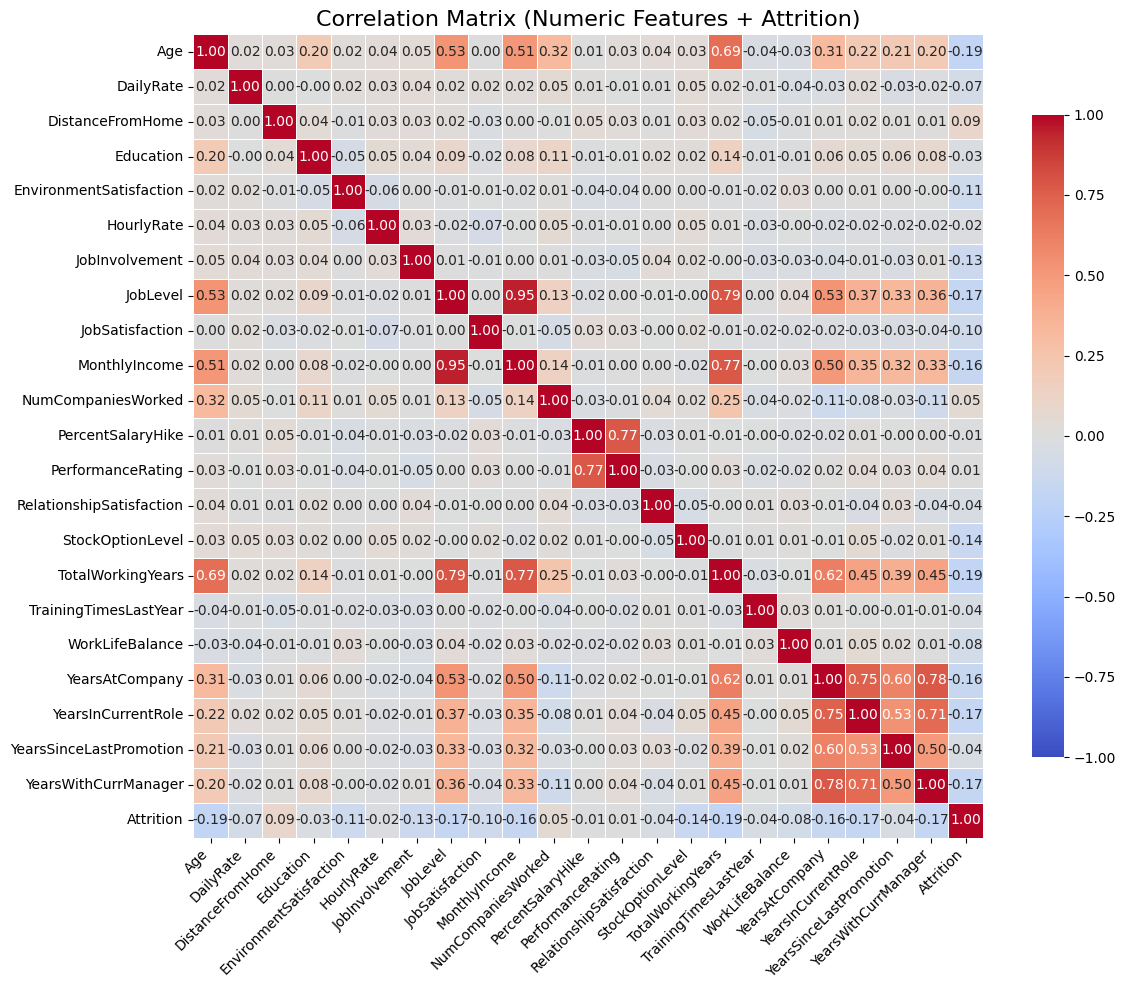

=== Top 10 Features by Mutual Information with Attrition ===


MonthlyIncome           0.036437
TotalWorkingYears       0.034253
StockOptionLevel        0.033652
OverTime_No             0.021222
OverTime_Yes            0.021222
JobLevel                0.019995
NumCompaniesWorked      0.018007
YearsInCurrentRole      0.016312
YearsWithCurrManager    0.015853
Age                     0.015525
dtype: float64

C:\Users\narji\AppData\Local\Temp\ipykernel_11492\3087584259.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


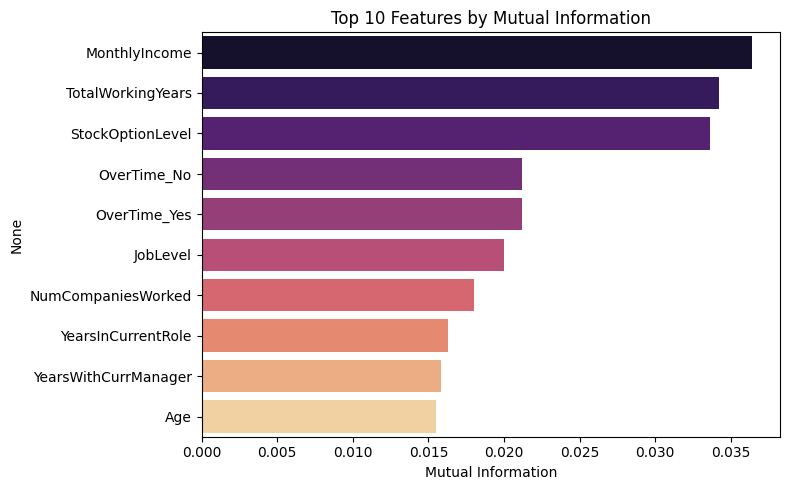

=== Top 10 RandomForest Feature Importances ===


OverTime_No             0.072951
OverTime_Yes            0.067805
StockOptionLevel        0.055909
Age                     0.042064
YearsWithCurrManager    0.039242
YearsAtCompany          0.037586
JobLevel                0.037033
TotalWorkingYears       0.036659
MonthlyIncome           0.035897
MaritalStatus_Single    0.033929
dtype: float64

C:\Users\narji\AppData\Local\Temp\ipykernel_11492\3087584259.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


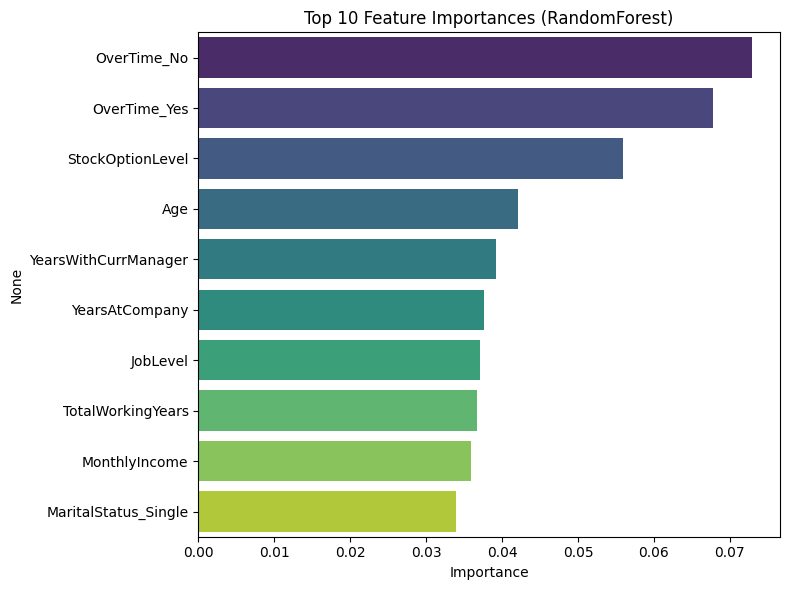

In [6]:
# 3c. Three features selection methods: Correlation Heatmap (Numeric Features) + Feature–Target Associations via Mutual Information + Random Forest Feature Importances (on SMOTE-balanced data)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# Correlation Heatmap (Numeric Features + Attrition)

# Identify numeric cols that actually vary
varying_num_cols = [
    c for c in num_cols
    if X_train[c].nunique() > 1
]

# Build a small DataFrame with those plus the target
corr_df = pd.concat([
    X_train[varying_num_cols],
    y_train.rename('Attrition')
], axis=1)

# Compute correlation matrix
corr = corr_df.corr()

# Plot
plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    vmax=1.0, vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink':0.8}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Matrix (Numeric Features + Attrition)", fontsize=16)
plt.tight_layout()
plt.show()

# Feature–Target Associations via Mutual Information

# Encode & scale the training set via your existing preprocessor
X_train_enc = preprocessor.fit_transform(X_train)

# Build a list of **all** feature names in the same order as X_train_enc columns
ohe = preprocessor.named_transformers_['ohe']
ohe_feats = list(ohe.get_feature_names_out(cat_cols))
all_feats = ohe_feats + num_cols

# Compute MI scores (discrete_features mask: True for OHE cols, False for numeric)
discrete_mask = [True]*len(ohe_feats) + [False]*len(num_cols)
mi_scores = mutual_info_classif(
    X_train_enc, 
    y_train, 
    discrete_features=discrete_mask,
    random_state=42
)

# Wrap into a Series and sort
mi_series = pd.Series(mi_scores, index=all_feats).sort_values(ascending=False)

print("=== Top 10 Features by Mutual Information with Attrition ===")
display(mi_series.head(10))

# Plot top 10 MI scores
plt.figure(figsize=(8,5))
sns.barplot(
    x=mi_series.head(10).values,
    y=mi_series.head(10).index,
    palette='magma'
)
plt.title("Top 10 Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

# Random Forest Feature Importances (on SMOTE-balanced data)

from sklearn.ensemble import RandomForestClassifier

# Fit a RF on your resampled & encoded data
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

# Pull out feature importances
importances = pd.Series(
    rf.feature_importances_, 
    index=all_feats
).sort_values(ascending=False)

top10 = importances.head(10)

print("=== Top 10 RandomForest Feature Importances ===")
display(top10)

# Plot them
plt.figure(figsize=(8,6))
sns.barplot(
    x=top10.values, 
    y=top10.index, 
    palette="viridis"
)
plt.title("Top 10 Feature Importances (RandomForest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 4. Modeling
We train two advanced ensembles:
1. XGBoost  
2. LightGBM  

We'll wrap each in a Pipeline and use StratifiedKFold cross-validation.


XGBoost CV ROC AUC: 0.810 ± 0.042
Optimal threshold (Youden's J): 0.026
 → TPR = 0.702, FPR = 0.259


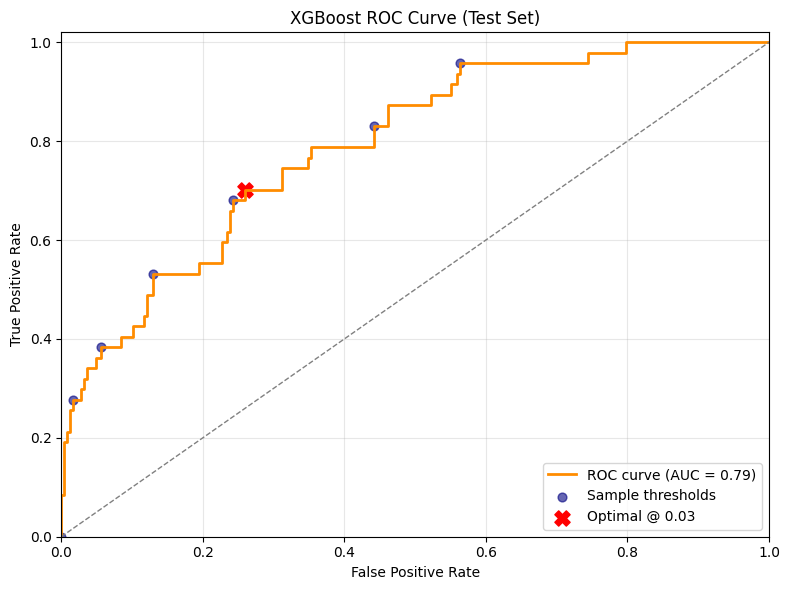

In [7]:
# 4a. XGBoost modeling
import warnings
warnings.filterwarnings("ignore")               # silence sklearn & XGBoost warnings
import xgboost as xgb
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# build pipeline
xgb_clf = Pipeline([
    ('prep', preprocessor),
    ('smote', smote),
    ('model', xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0           # suppress XGBoost info logs
    ))
])

# 5-fold CV ROC AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb_clf, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)
print(f"XGBoost CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Fit on train, predict on test
xgb_clf.fit(X_train, y_train)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

# Compute ROC curve & AUC on test set
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Find optimal threshold via Youden’s J = TPR – FPR
youden_j = tpr - fpr
ix = np.argmax(youden_j)
opt_thresh = thresholds[ix]
opt_tpr, opt_fpr = tpr[ix], fpr[ix]
print(f"Optimal threshold (Youden's J): {opt_thresh:.3f}")
print(f" → TPR = {opt_tpr:.3f}, FPR = {opt_fpr:.3f}")

# Plot ROC + optimal point
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.scatter(fpr[::10], tpr[::10], color='navy', s=40, alpha=0.6, label='Sample thresholds')
plt.scatter(opt_fpr, opt_tpr, color='red', s=120, marker='X',
            label=f'Optimal @ {opt_thresh:.2f}')
plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
plt.xlim(0,1); plt.ylim(0,1.02)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve (Test Set)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

LightGBM CV ROC AUC: 0.815 ± 0.047
Optimal threshold (Youden's J): 0.028
 → TPR=0.787, FPR=0.287


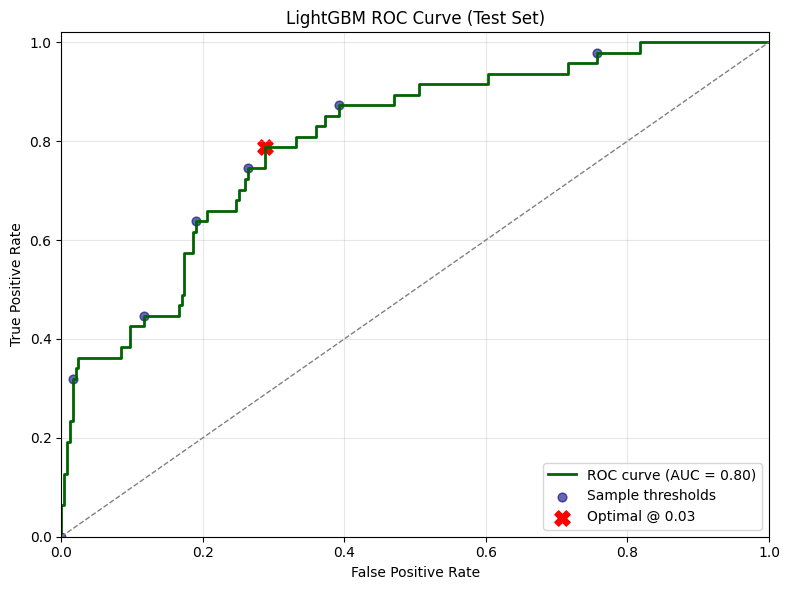

In [8]:
# 4b. LightGBM modeling
import warnings
warnings.filterwarnings("ignore")               # silence sklearn FutureWarnings etc.
import lightgbm as lgb
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# build pipeline (note verbose=-1 in LGBMClassifier to suppress info logs)
lgb_clf = Pipeline([
    ('prep', preprocessor),
    ('smote', smote),
    ('model', lgb.LGBMClassifier(
        random_state=42,
        verbose=-1,        # no LightGBM info during fit
        n_jobs=-1
    ))
])

# cross-val ROC AUC (5-fold stratified)
cv_scores = cross_val_score(
    lgb_clf,
    X_train, y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
print(f"LightGBM CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Fit on full train, predict on test
lgb_clf.fit(X_train, y_train)
y_prob = lgb_clf.predict_proba(X_test)[:, 1]

# Compute ROC curve & AUC on test set
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Find optimal threshold by Youden’s J = TPR–FPR
youden_j = tpr - fpr
ix = np.argmax(youden_j)
opt_thresh = thresholds[ix]
opt_tpr, opt_fpr = tpr[ix], fpr[ix]
print(f"Optimal threshold (Youden's J): {opt_thresh:.3f}")
print(f" → TPR={opt_tpr:.3f}, FPR={opt_fpr:.3f}")

# Plot ROC + optimal point
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkgreen', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
# all threshold points (every 10th)
plt.scatter(fpr[::10], tpr[::10], color='navy', s=40, alpha=0.6, label='Sample thresholds')
# optimal
plt.scatter(opt_fpr, opt_tpr, color='red', s=120, marker='X',
            label=f'Optimal @ {opt_thresh:.2f}')
plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
plt.xlim(0,1); plt.ylim(0,1.02)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('LightGBM ROC Curve (Test Set)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

13/13 [==============================] - 0s 947us/step
 Fold 1 AUC: 0.997
13/13 [==============================] - 0s 1ms/step
 Fold 2 AUC: 0.992
13/13 [==============================] - 0s 1ms/step
 Fold 3 AUC: 0.993
13/13 [==============================] - 0s 6ms/step
 Fold 4 AUC: 0.978
13/13 [==============================] - 0s 1ms/step
 Fold 5 AUC: 0.982

MLP CV ROC AUC: 0.988 ± 0.007
10/10 [==============================] - 0s 936us/step

MLP Test ROC AUC: 0.664
Optimal threshold (Youden's J): 0.524
 → TPR=0.681, FPR=0.328


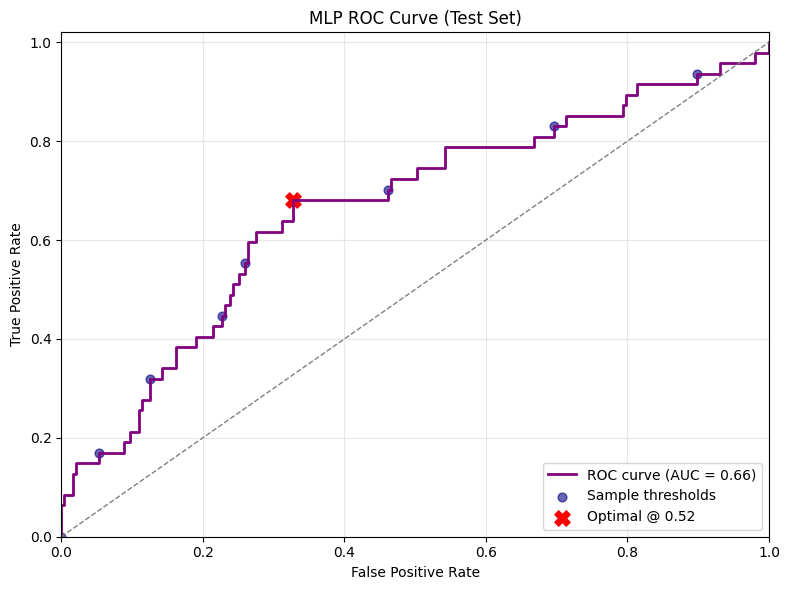

In [9]:
# 4c. BONUS – Deep Learning (MLP) with manual CV & tuning
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score

# --- Prepare resampled train set once ---
# (we assume preprocessor & SMOTE are already defined)
X_train_enc = preprocessor.fit_transform(X_train)
X_res, y_res = smote.fit_resample(X_train_enc, y_train)

# --- Define tuned MLP builder ---
def build_mlp():
    m = models.Sequential([
        layers.Input(shape=(X_res.shape[1],)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return m

# --- Manual 5-fold CV on resampled data ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_res, y_res), 1):
    model = build_mlp()
    es = EarlyStopping(
        monitor="val_auc", mode="max",
        patience=10, restore_best_weights=True, verbose=0
    )
    history = model.fit(
        X_res[tr_idx], y_res[tr_idx],
        validation_data=(X_res[va_idx], y_res[va_idx]),
        epochs=200,
        batch_size=64,
        callbacks=[es],
        verbose=0
    )
    # predict on validation
    y_val_prob = model.predict(X_res[va_idx]).ravel()
    fold_auc = roc_auc_score(y_res[va_idx], y_val_prob)
    print(f" Fold {fold} AUC: {fold_auc:.3f}")
    fold_aucs.append(fold_auc)

print(f"\nMLP CV ROC AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

# --- Final fit on full resampled set & test evaluation ---
final_model = build_mlp()
es = EarlyStopping(monitor="val_auc", mode="max", patience=10, restore_best_weights=True, verbose=0)
final_model.fit(
    X_res, y_res,
    validation_split=0.1,
    epochs=200,
    batch_size=64,
    callbacks=[es],
    verbose=0
)

# prep test set, predict
X_test_enc = preprocessor.transform(X_test)
y_prob = final_model.predict(X_test_enc).ravel()

# ROC & Youden’s J
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
youden_j = tpr - fpr
ix = np.argmax(youden_j)
opt_thresh = thresholds[ix]
opt_tpr, opt_fpr = tpr[ix], fpr[ix]

print(f"\nMLP Test ROC AUC: {roc_auc:.3f}")
print(f"Optimal threshold (Youden's J): {opt_thresh:.3f}")
print(f" → TPR={opt_tpr:.3f}, FPR={opt_fpr:.3f}")

# --- Plot ROC + thresholds ---
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.scatter(fpr[::10], tpr[::10], color='navy', s=40, alpha=0.6, label='Sample thresholds')
plt.scatter(opt_fpr, opt_tpr, color='red', s=120, marker='X', label=f'Optimal @ {opt_thresh:.2f}')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlim(0,1); plt.ylim(0,1.02)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('MLP ROC Curve (Test Set)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Model Evaluation
- Final train on full train set  
- Evaluate on hold-out test: ROC AUC, classification_report  
- Interpret with SHAP  
- Fairness check (AIF360)


In [10]:
# 5a. Fit final and evaluate (XGB, LGB, MLP)
from sklearn.metrics import classification_report, roc_auc_score

# 1) XGBoost & LightGBM (both are in sklearn‐style Pipelines)
for name, model in [
    ("XGBoost",  xgb_clf),
    ("LightGBM", lgb_clf)
]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n--- {name} on test set ---")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"Test ROC AUC: {roc_auc_score(y_test, y_prob):.3f}")

# 2) MLP (final_model from section 4c)

y_prob_mlp = final_model.predict(X_test_enc).ravel()
# turn your Youden's‐J threshold into a hard cutoff
y_pred_mlp = (y_prob_mlp >= opt_thresh).astype(int)

print(f"\n--- MLP on test set ---")
print(classification_report(y_test, y_pred_mlp, digits=3))
print(f"Test ROC AUC: {roc_auc:.3f}")



--- XGBoost on test set ---
              precision    recall  f1-score   support

           0      0.884     0.960     0.920       247
           1      0.615     0.340     0.438        47

    accuracy                          0.861       294
   macro avg      0.750     0.650     0.679       294
weighted avg      0.841     0.861     0.843       294

Test ROC AUC: 0.791

--- LightGBM on test set ---
              precision    recall  f1-score   support

           0      0.884     0.984     0.931       247
           1      0.789     0.319     0.455        47

    accuracy                          0.878       294
   macro avg      0.837     0.651     0.693       294
weighted avg      0.869     0.878     0.855       294

Test ROC AUC: 0.802
10/10 [==============================] - 0s 1ms/step

--- MLP on test set ---
              precision    recall  f1-score   support

           0      0.917     0.672     0.776       247
           1      0.283     0.681     0.400        47

    a

In [11]:
# ── Build & Train best_clf (LightGBM) for SHAP ─────────────────────────────────────

from imblearn.pipeline import Pipeline
import lightgbm as lgb

best_clf = Pipeline([
    ('prep', preprocessor),          # ColumnTransformer
    ('smote', smote),                # SMOTE sampler
    ('model', lgb.LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

# fit on train set
best_clf.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime']),
                                                 ('scale', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatis...
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOptionLevel',
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LGBMClassifier(n_jobs=-1, random_state=42, verbose=-1))])

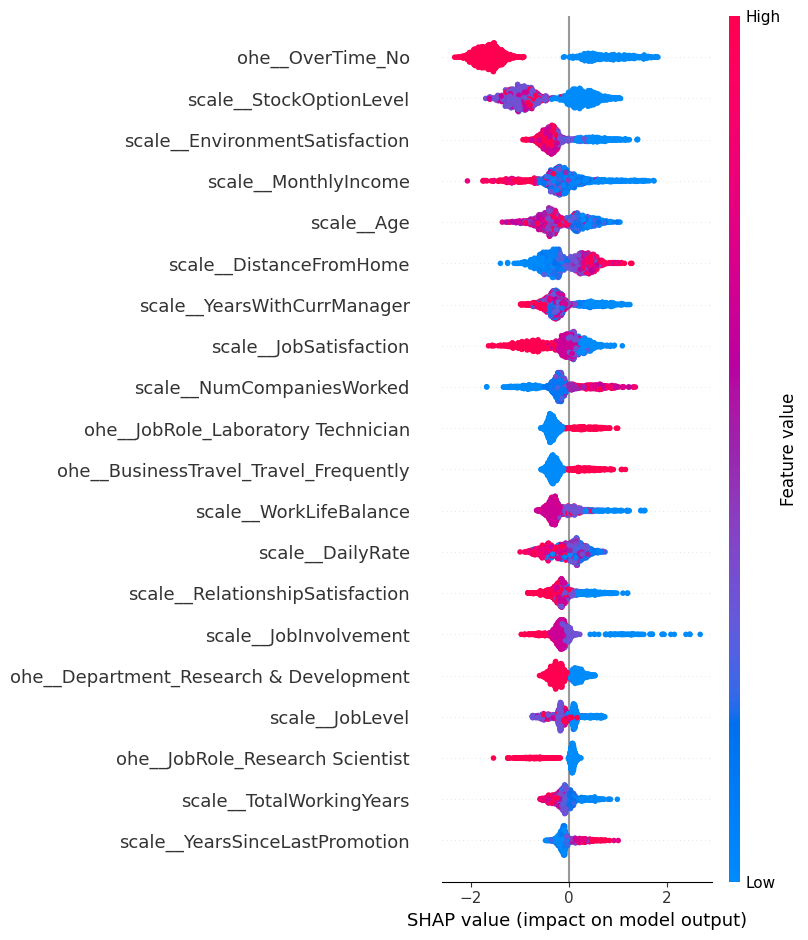

In [12]:
# 5b. Explainability with SHAP
import shap

# extract model and data
model = best_clf.named_steps['model']
X_train_prepped = best_clf.named_steps['prep'].transform(X_train)

explainer = shap.Explainer(model)
shap_values = explainer(X_train_prepped)

shap.summary_plot(shap_values, X_train_prepped, feature_names=best_clf.named_steps['prep'].get_feature_names_out())


In [13]:
# 5c. Bias and Fairness Assessment
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

# 1) Apply the exact same preprocessor you used for modeling
X_test_num = preprocessor.transform(X_test)

# 2) Recover the numeric feature names in the same order
feat_names = preprocessor.get_feature_names_out()

# 3) Build a DataFrame so we can concatenate the 0/1 label
df_test_num = pd.DataFrame(
    X_test_num, 
    columns=feat_names, 
    index=X_test.index
)
df_test_num['Attrition'] = y_test.values

# 4) Choose the one‐hot‐encoded "privileged" gender column
#    (assuming OneHotEncoder created these two)
protected_col = 'ohe__Gender_Male'

# 5) Create the AIF360 BinaryLabelDataset
test_bld = BinaryLabelDataset(
    df=df_test_num,
    label_names=['Attrition'],
    protected_attribute_names=[protected_col],
    favorable_label=0,   # "stayed" = good
    unfavorable_label=1  # "left"   = bad
)

# 6) Inject your model’s predictions
preds = best_clf.predict(X_test)
test_bld_pred = test_bld.copy()
test_bld_pred.labels = preds.reshape(-1, 1)

# 7) Compute fairness metrics
metric = ClassificationMetric(
    test_bld,
    test_bld_pred,
    unprivileged_groups=[{protected_col: 0}],   # Female
    privileged_groups=[{protected_col: 1}]      # Male
)

print("Disparate Impact:             ", metric.disparate_impact())
print("Statistical Parity Difference:", metric.statistical_parity_difference())


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


Disparate Impact:              1.0075820523473205
Statistical Parity Difference: 0.007070902750871855


## 6. Deployment
Save pipeline for production.


In [14]:
import cloudpickle
with open('model.pkl', 'wb') as f:
    cloudpickle.dump(best_clf, f)

print("Model pipeline saved.")

Model pipeline saved.


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Predicting Employee Performance

**Author:** Narjis Jebali 
**Date:** 2025-05-02  

## 1. Problem Definition

We aim to predict which employees will achieve an “Outstanding” performance rating (4) versus “Excellent” (3), so leadership can tailor development and recognition. We’ll apply our end-to-end ML pipeline:

- **Ensemble models** (XGBoost, LightGBM)  
- **Explainability** (SHAP)  
- **Fairness checks** (AIF360)  
- **Robust validation** (stratified CV, ROC AUC)  


## 2. Data Understanding

**Dataset shape**  
- **Rows × Columns**: 1 470 × 30  

**Data types & missing values**  
- **Numeric** (22 columns): `int64` — no missing values  
- **Categorical** (8 columns): `object` — no missing values  
(the dataset has already been cleaned and processed in the attrition part above)

**PerformanceRating (target)**  
- **Original scale** (1 – 4):  
  1. Low Performer  
  2. Good  
  3. Excellent  
  4. Outstanding  
- **In our sample** only values **3** and **4** appear:  
  - **3 = Excellent**  
  - **4 = Outstanding**  
- This reduces to a two-class distinction (Excellent vs. Outstanding), with no “Low” or “Good” performers in the data  
- Distribution is imbalanced (majority rated Excellent)  

> _Note: when we model “PerformanceRating,” we’ll either treat it as a binary classification (3 vs. 4) or as an ordinal regression on this two-level scale._  


In [15]:
import pandas as pd
df = pd.read_csv('dataset.csv')
print(df.shape)
display(df.head())
display(df.info())
display(df['PerformanceRating'].value_counts(normalize=True))

(1470, 30)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

None

PerformanceRating
3    0.846259
4    0.153741
Name: proportion, dtype: float64

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


Text(0.5, 1.0, 'PerformanceRating Distribution')

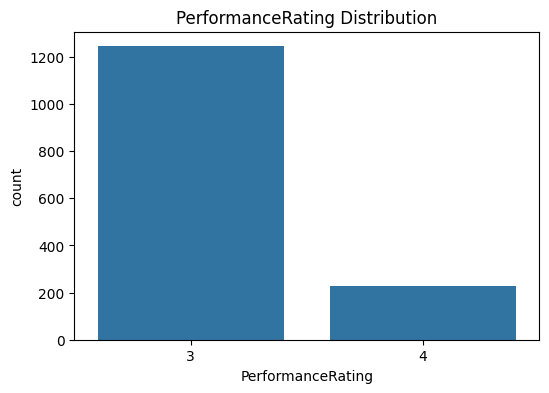

In [16]:
# Quick EDA (Exploratory Data Analysis): numeric summaries and pairwise target correlations
display(df.describe().T)
import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.countplot(x='PerformanceRating', data=df)
plt.title('PerformanceRating Distribution')

## 3. Data Processing
- Binarize `PerformanceRating` (4 → “Outstanding” = 1; 3 → “Excellent” = 0)  
- Handle missing values  
- Encode categoricals (One-Hot)  
- Scale numerical features  
- Train/test split (80/20, stratified on new target)  
- SMOTE on training set to balance classes  
- Feature–target associations (correlation + mutual information)  


In [34]:
# 3a. Preprocessing pipeline setup (PerformanceRating)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Identify features
target = 'PerformanceRating'
# drop both the target and the leaky PercentSalaryHike column
X = df.drop(columns=[target, 'PercentSalaryHike'])
# Map 3→0 (low performance), 4→1 (high performance)
y = df[target].map({3: 0, 4: 1})

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Categorical vs numerical
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('scale', StandardScaler(), num_cols)
])

# SMOTE for class balance
smote = SMOTE(random_state=42)

Balanced PerformanceRating distribution: Counter({1: 995, 0: 995})


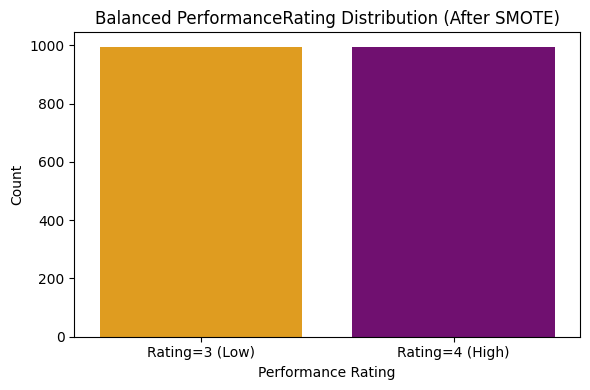

In [35]:
# 3b. Print new balanced target distribution

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Fit & transform your training set
X_train_enc = preprocessor.fit_transform(X_train)

# 2) Resample to balance
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

# 3) Print the new counts
print("Balanced PerformanceRating distribution:", Counter(y_train_res))

# 4) Plot it
plt.figure(figsize=(6,4))
sns.countplot(
    x=y_train_res,
    palette=['orange','purple']    # first bar = orange (0), second = purple (1)
)
plt.xticks([0,1], ['Rating=3 (Low)','Rating=4 (High)'])
plt.xlabel('Performance Rating')
plt.ylabel('Count')
plt.title('Balanced PerformanceRating Distribution (After SMOTE)')
plt.tight_layout()
plt.show()

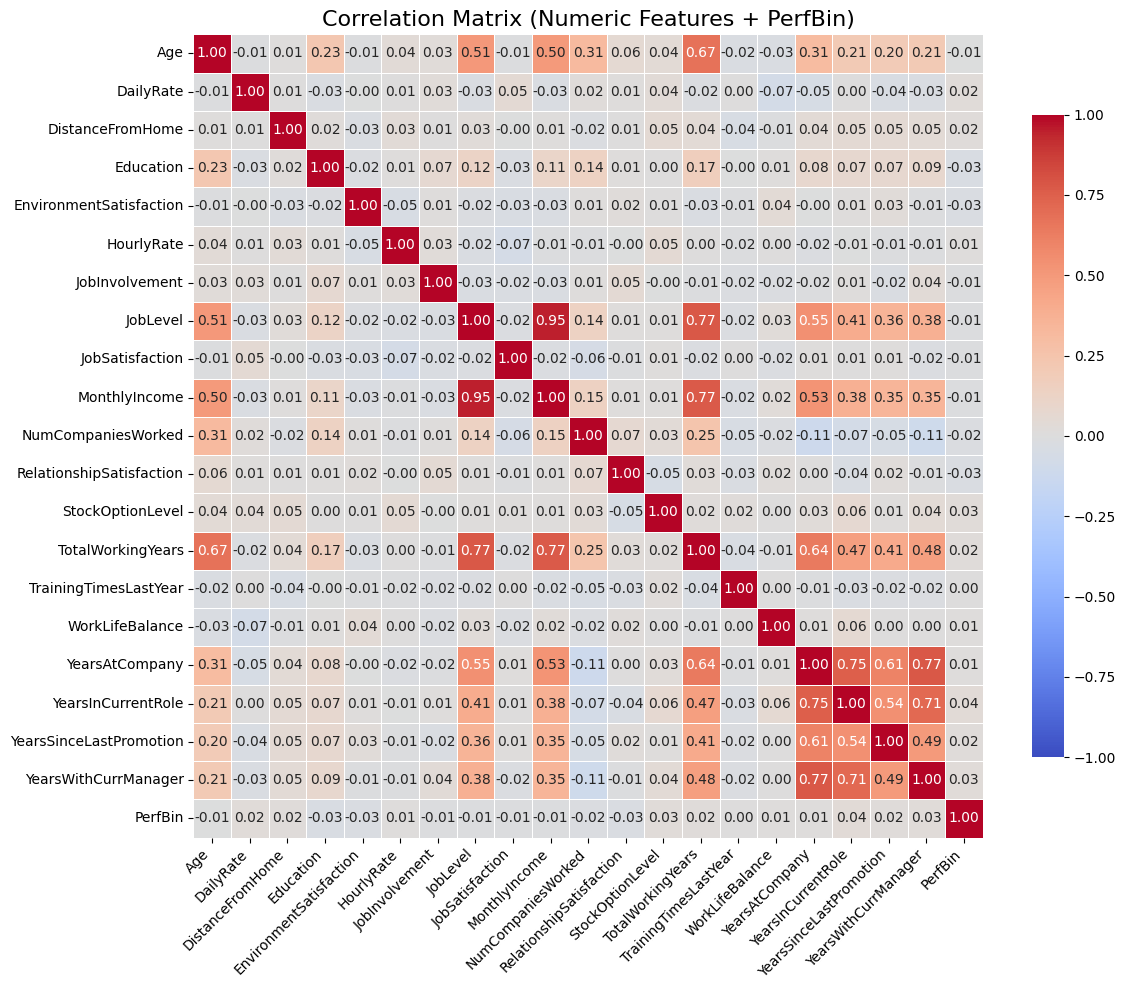

=== Top 10 Features by Mutual Information with PerfBin ===


scale__NumCompaniesWorked       0.018439
scale__TotalWorkingYears        0.015566
scale__YearsWithCurrManager     0.014335
scale__JobLevel                 0.004203
scale__StockOptionLevel         0.002859
scale__Age                      0.002440
scale__YearsAtCompany           0.001196
ohe__JobRole_Manager            0.000951
ohe__JobRole_Sales Executive    0.000790
scale__DailyRate                0.000763
dtype: float64

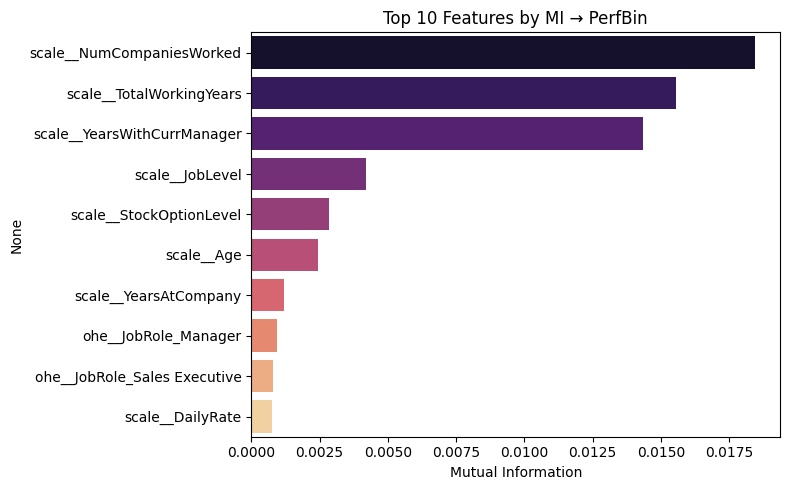

=== Top 10 RF Feature Importances for PerfBin ===


scale__TrainingTimesLastYear         0.046213
ohe__EducationField_Life Sciences    0.045090
ohe__MaritalStatus_Married           0.043682
scale__StockOptionLevel              0.040486
scale__HourlyRate                    0.033136
scale__NumCompaniesWorked            0.032961
scale__Age                           0.032664
scale__DailyRate                     0.032631
scale__RelationshipSatisfaction      0.031448
scale__MonthlyIncome                 0.030453
dtype: float64

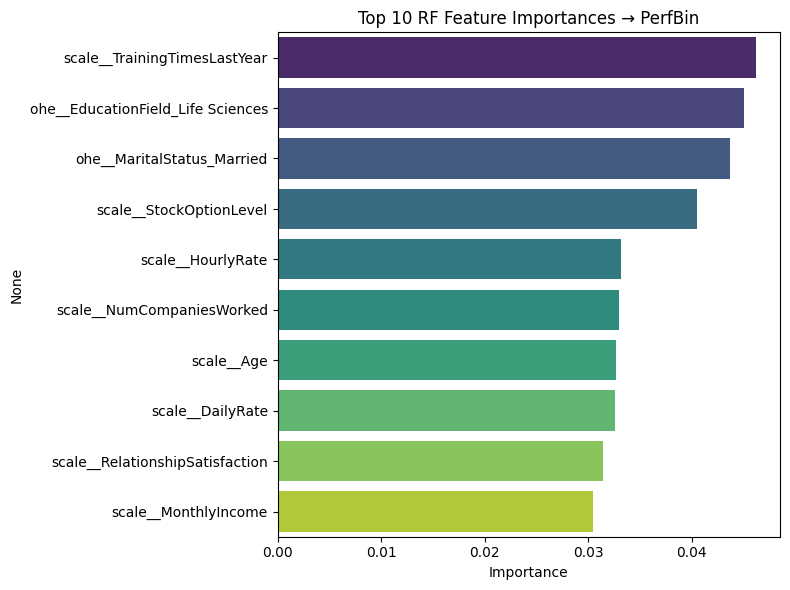

In [43]:
# 3c. Three feature‐selection methods for PerfBin:
#    1) Correlation heatmap (numeric)
#    2) Mutual Information
#    3) RandomForest importances (on SMOTE‐balanced)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# --- 0) Fit your preprocessor on X_train so get_feature_names_out() matches transform() ---
preprocessor.fit(X_train)

# Now pull the exact list of encoded feature names
feat_names = preprocessor.get_feature_names_out()

# --- 1) Correlation Heatmap (Numeric Features + PerfBin) ---
# numeric columns should already have PerfBin dropped out
varying_num_cols = [c for c in num_cols if X_train[c].nunique() > 1]

corr_df = pd.concat([
    X_train[varying_num_cols],
    y_train.rename('PerfBin')
], axis=1)

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_df.corr(),
    cmap='coolwarm', vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt=".2f", linewidths=0.5,
    cbar_kws={'shrink':0.8}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Matrix (Numeric Features + PerfBin)", fontsize=16)
plt.tight_layout()
plt.show()

# --- 2) Mutual Information ---
# transform X_train once
X_train_enc = preprocessor.transform(X_train)

mi_scores = mutual_info_classif(
    X_train_enc,
    y_train,
    discrete_features=[name.startswith('ohe__') for name in feat_names],
    random_state=42
)

mi_series = pd.Series(mi_scores, index=feat_names).sort_values(ascending=False)
print("=== Top 10 Features by Mutual Information with PerfBin ===")
display(mi_series.head(10))

plt.figure(figsize=(8,5))
sns.barplot(x=mi_series.head(10).values, y=mi_series.head(10).index, palette='magma')
plt.title("Top 10 Features by MI → PerfBin")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

# --- 3) RandomForest Feature Importances (on SMOTE-balanced data) ---
# first resample (if you haven't already):
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

rf = RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

# now lengths will match exactly
importances = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
top10 = importances.head(10)

print("=== Top 10 RF Feature Importances for PerfBin ===")
display(top10)

plt.figure(figsize=(8,6))
sns.barplot(x=top10.values, y=top10.index, palette="viridis")
plt.title("Top 10 RF Feature Importances → PerfBin")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 4. Modeling
We train two advanced ensembles:
1. XGBoost  
2. LightGBM  

We'll wrap each in a Pipeline and use StratifiedKFold cross-validation.


XGBoost CV ROC AUC (Perf): 0.468 ± 0.042
Optimal threshold (Youden's J): 0.127
 → TPR = 0.267, FPR = 0.133


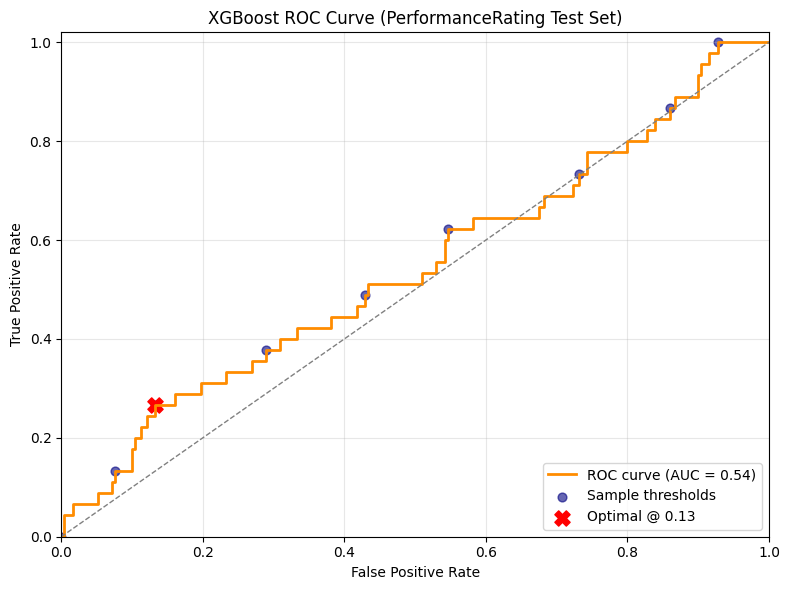

In [44]:
# 4a. XGBoost modeling for PerformanceRating
import warnings
warnings.filterwarnings("ignore")                # mute warnings
import xgboost as xgb
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# build a pipeline: preprocess → balance → XGBClassifier
xgb_perf = Pipeline([
    ('prep', preprocessor),          # your ColumnTransformer from §3
    ('smote', smote),                # handles any class imbalance
    ('model', xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0                  # suppress XGBoost logs
    ))
])

# 5-fold stratified cross-val on PerformanceRating (binary)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb_perf,
    X_train,         # from your train/test split on PerfBin
    y_train,         # PerfBin: e.g. 1 if PerformanceRating==4 else 0
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
print(f"XGBoost CV ROC AUC (Perf): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# fit on full training data, then get test set probabilities
xgb_perf.fit(X_train, y_train)
y_prob = xgb_perf.predict_proba(X_test)[:, 1]

# compute ROC curve & AUC on hold-out test
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# find optimal threshold via Youden’s J = TPR – FPR
youden_j = tpr - fpr
ix = np.argmax(youden_j)
opt_thresh = thresholds[ix]
opt_tpr, opt_fpr = tpr[ix], fpr[ix]
print(f"Optimal threshold (Youden's J): {opt_thresh:.3f}")
print(f" → TPR = {opt_tpr:.3f}, FPR = {opt_fpr:.3f}")

# plot ROC curve + sample & optimal points
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.scatter(fpr[::10], tpr[::10], color='navy', s=40, alpha=0.6,
            label='Sample thresholds')
plt.scatter(opt_fpr, opt_tpr, color='red', s=120, marker='X',
            label=f'Optimal @ {opt_thresh:.2f}')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlim(0,1); plt.ylim(0,1.02)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve (PerformanceRating Test Set)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


LightGBM CV ROC AUC (Performance): 0.494 ± 0.050
Optimal threshold (Youden's J): 0.025
 → TPR = 0.889, FPR = 0.747


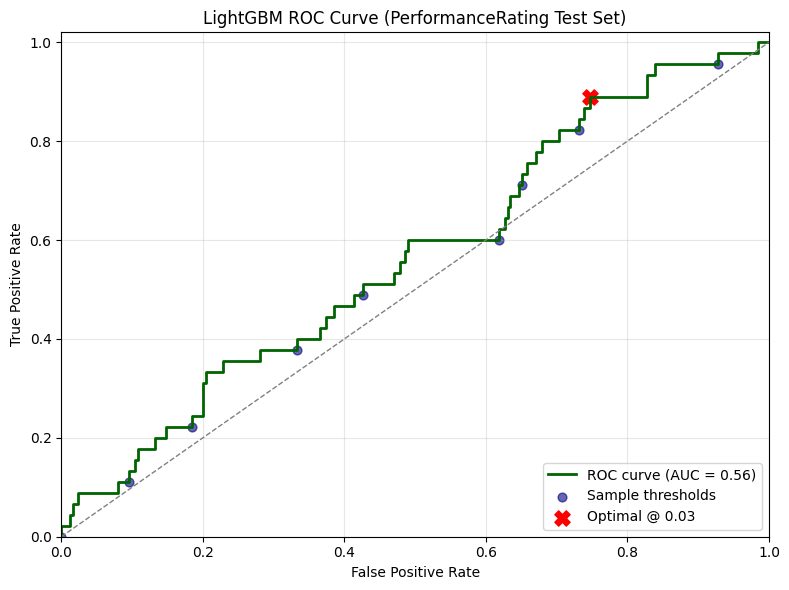

In [45]:
# 4b. LightGBM modeling for PerformanceRating
import warnings
warnings.filterwarnings("ignore")
import lightgbm as lgb
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# build pipeline (verbose=-1 to suppress LightGBM info logs)
lgb_perf_clf = Pipeline([
    ('prep', preprocessor),
    ('smote', smote),
    ('model', lgb.LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

# 5-fold CV ROC AUC (on the PerformanceRating train set)
cv_scores = cross_val_score(
    lgb_perf_clf,
    X_train, y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
print(f"LightGBM CV ROC AUC (Performance): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Fit on full train, predict on test
lgb_perf_clf.fit(X_train, y_train)
y_prob = lgb_perf_clf.predict_proba(X_test)[:, 1]

# Compute ROC curve & AUC on test set
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
perf_roc_auc = auc(fpr, tpr)

# Find optimal threshold by Youden’s J = TPR – FPR
youden_j = tpr - fpr
ix = np.argmax(youden_j)
opt_thresh, opt_tpr, opt_fpr = thresholds[ix], tpr[ix], fpr[ix]
print(f"Optimal threshold (Youden's J): {opt_thresh:.3f}")
print(f" → TPR = {opt_tpr:.3f}, FPR = {opt_fpr:.3f}")

# Plot ROC + optimal point
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkgreen', lw=2,
         label=f'ROC curve (AUC = {perf_roc_auc:.2f})')
plt.scatter(fpr[::10], tpr[::10], color='navy', s=40, alpha=0.6, label='Sample thresholds')
plt.scatter(opt_fpr, opt_tpr, color='red', s=120, marker='X',
            label=f'Optimal @ {opt_thresh:.2f}')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlim(0,1); plt.ylim(0,1.02)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('LightGBM ROC Curve (PerformanceRating Test Set)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Model Evaluation
- Final train on full train set  
- Evaluate on hold-out test: ROC AUC, classification_report  
- Interpret with SHAP  
- Fairness check (AIF360)

In [46]:
# 5a. Fit final and evaluate (XGBoost & LightGBM) on PerformanceRating
from sklearn.metrics import classification_report, roc_auc_score

# Replace these with whatever you named your performance‐target pipelines
models = [
    ("XGBoost",  xgb_perf),
    ("LightGBM", lgb_perf_clf)
]

for name, model in models:
    # retrain on full train set
    model.fit(X_train, y_train)
    # predict classes & probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n--- {name} on PerformanceRating test set ---")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"Test ROC AUC: {roc_auc_score(y_test, y_prob):.3f}")



--- XGBoost on PerformanceRating test set ---
              precision    recall  f1-score   support

           0      0.849     0.996     0.917       249
           1      0.500     0.022     0.043        45

    accuracy                          0.847       294
   macro avg      0.675     0.509     0.480       294
weighted avg      0.796     0.847     0.783       294

Test ROC AUC: 0.541

--- LightGBM on PerformanceRating test set ---
              precision    recall  f1-score   support

           0      0.849     0.996     0.917       249
           1      0.500     0.022     0.043        45

    accuracy                          0.847       294
   macro avg      0.675     0.509     0.480       294
weighted avg      0.796     0.847     0.783       294

Test ROC AUC: 0.565
